In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns



df = pd.read_csv('heart.csv')

In [3]:
print("info\n")
print(df.info) #data type


info

<bound method DataFrame.info of      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  Hear

In [4]:
# EDA
print("Shape\n")
print(df.shape)
print("Head\n")
print(df.head())





Shape

(918, 12)
Head

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [5]:
print("Describe\n")
df.describe() #gives numeric values and mean media

Describe



,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
# Null values
print(df.isnull().sum())

print(df.columns)

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')


In [7]:

df.duplicated().sum() #how many duplicates

np.int64(0)

<Axes: xlabel='HeartDisease'>

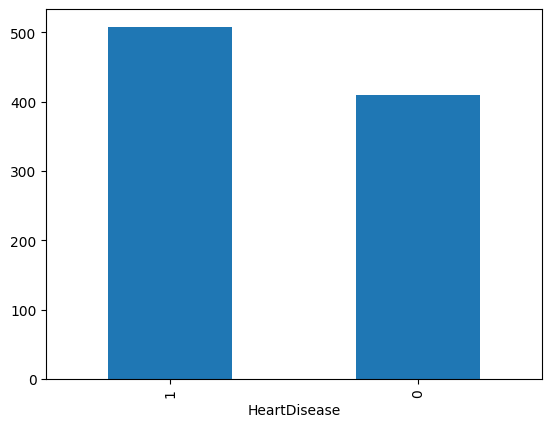

In [8]:
df['HeartDisease'].value_counts().plot(kind='bar')

Another way of visualizing numeric values without for loop and in a single picture

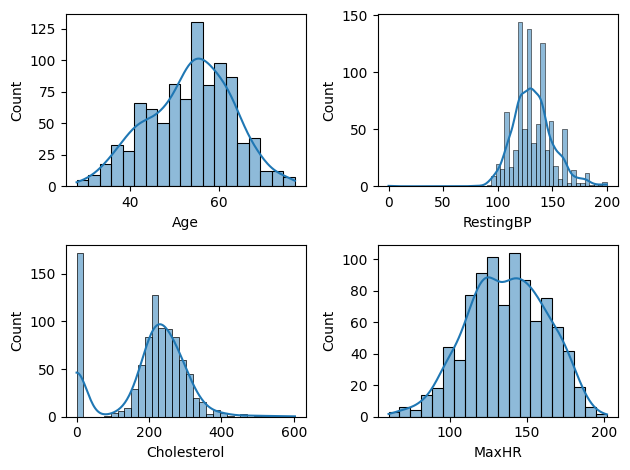

In [9]:
def plotting(colvar, quarter):
    plt.subplot(2,2,quarter)
    sns.histplot(df[colvar],kde=True)
    plt.tight_layout()
# numCols = ['Age', 'RestingBp', 'Cholesterol', 'MaxHR']
# var=0
# for col in numCols:
#     plotting(numCols[col], )

plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)


In [10]:
print(df['Cholesterol'].value_counts())

Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64


How to replace mean with particular values in a row for Cholestrol and resting bp col

In [11]:
mean=df.loc[df['Cholesterol']!=0, 'Cholesterol'].mean() # rows, col
print(mean)
df['Cholesterol']=df['Cholesterol'].replace(0,mean)
df['Cholesterol']=df['Cholesterol'].round()
df.head()

244.6353887399464


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


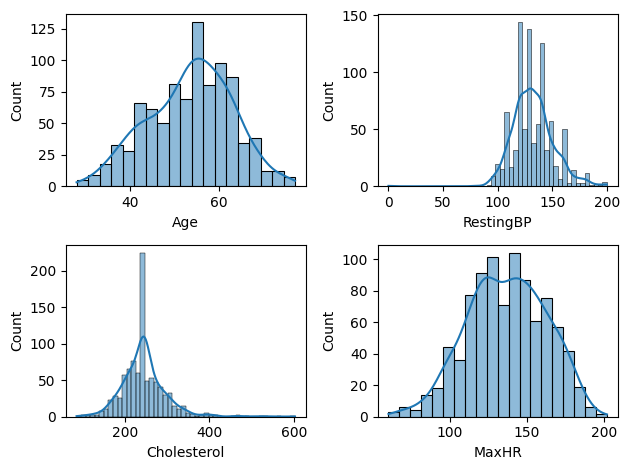

In [12]:

plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)

In [13]:
mean=df.loc[df['RestingBP']!=0, 'RestingBP'].mean() # rows, col
print(mean)
df['RestingBP']=df['RestingBP'].replace(0,mean)
df['RestingBP']=df['RestingBP'].round()
df.head()

132.54089422028352


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


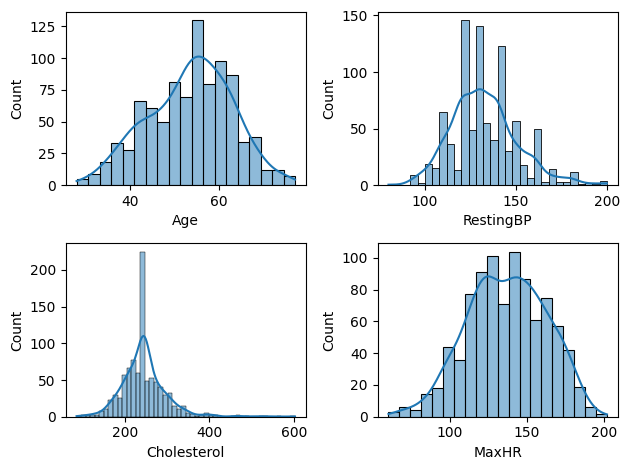

In [14]:

plotting('Age', 1)
plotting('RestingBP', 2)
plotting('Cholesterol', 3)
plotting('MaxHR', 4)


Now for categorical values  

<Axes: xlabel='ChestPainType', ylabel='count'>

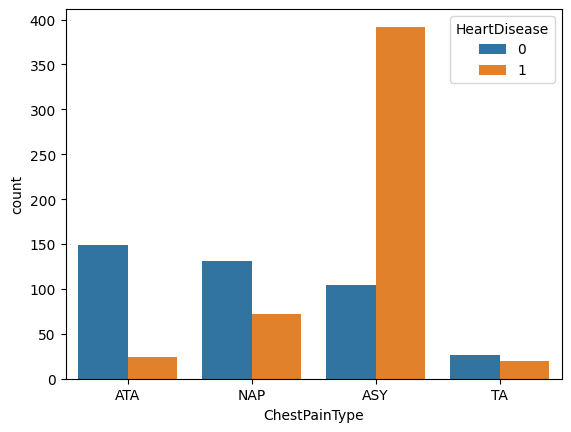

In [15]:
sns.countplot(x =df['ChestPainType'], hue=df['HeartDisease'])

<Axes: xlabel='Sex', ylabel='count'>

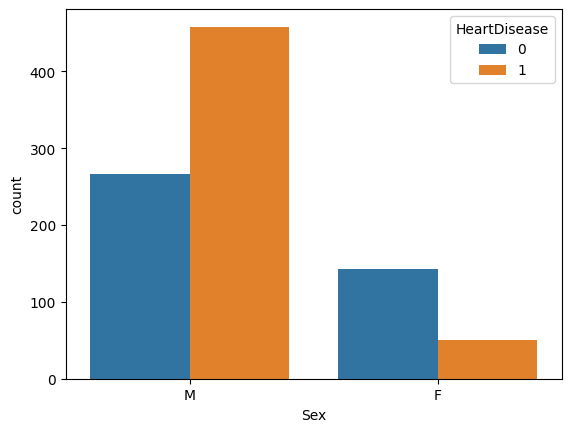

In [16]:
sns.countplot(x =df['Sex'], hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

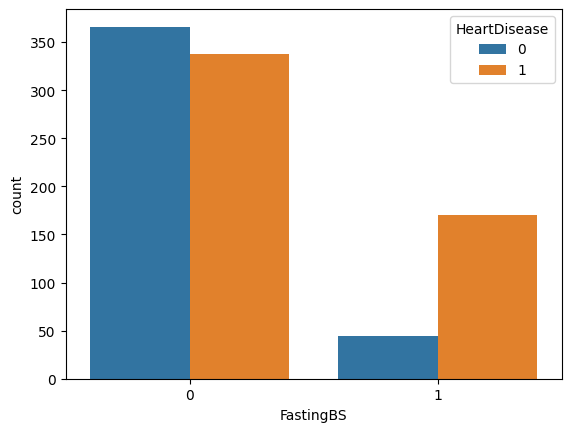

In [17]:
sns.countplot(x =df['FastingBS'], hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

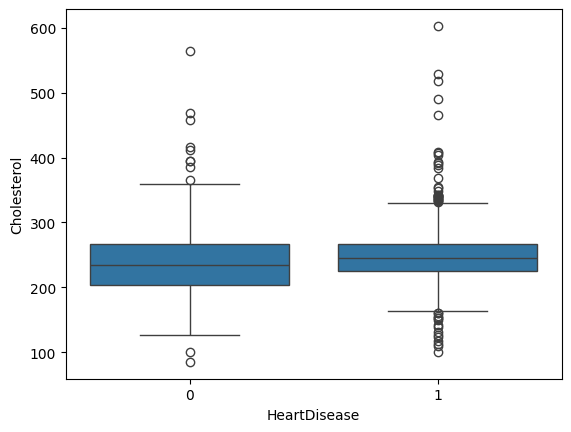

In [18]:
sns.boxplot(x='HeartDisease' ,y='Cholesterol',data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

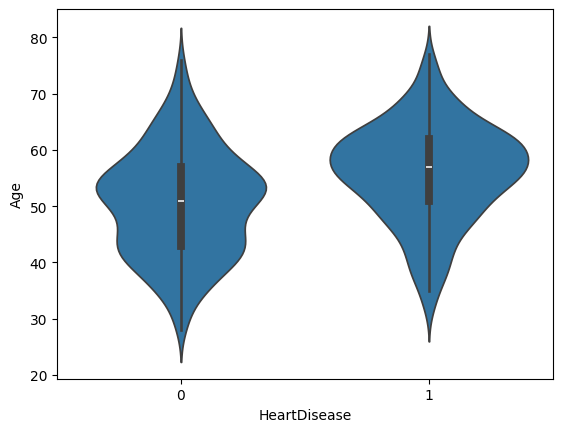

In [19]:
sns.violinplot(x='HeartDisease' ,y='Age',data = df)

<Axes: >

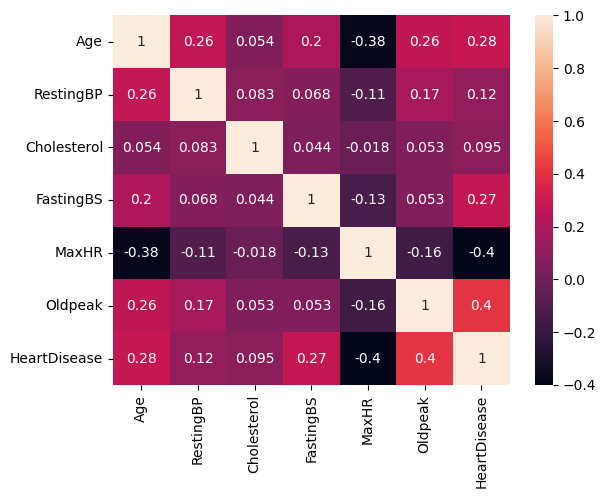

In [20]:

sns.heatmap(df.corr(numeric_only=True),annot=True)

Data Preprocessing and cleaning

Method 2 doing it all together converting everything using one-hot + label as we need everything num

For Numeric

In [22]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [ ]:

df_encoded = pd.get_dummies(df)

df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [ ]:
df_encoded=df_encoded.astype(int)
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

num_cols = ['Age','RestingBP','Cholesterol', 'MaxHR']
df_encoded[num_cols]=scaler.fit_transform(df_encoded[num_cols])

df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414825,0.831244,0,1.382928,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527163,-1.214200,0,0.754157,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141345,0.718651,0,-1.525138,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303591,-0.576172,0,-1.132156,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.970994,-0.932717,0,-0.581981,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


Now we'll do feature checking with target

In [ ]:
# Pearson
from scipy.stats import pearsonr

selected_features = ['Age',	'RestingBP'	,'Cholesterol'	,'FastingBS'	,'MaxHR'	,'Oldpeak'	,'HeartDisease',	'Sex_F',	'Sex_M'	,'ChestPainType_ASY', 'ChestPainType_ATA',	'ChestPainType_NAP'	,'ChestPainType_TA',	'RestingECG_LVH'	,'RestingECG_Normal',	'RestingECG_ST',	'ExerciseAngina_N',	'ExerciseAngina_Y'	,'ST_Slope_Down'	,'ST_Slope_Flat',	'ST_Slope_Up']


correlations = {
    feature: pearsonr(df_encoded[feature],df_encoded['HeartDisease'])[0]
    for feature in selected_features
}


# Creating a new df FOR pritig
corr_df = pd.DataFrame(list(correlations.items()), columns = ['Feature','pearsons val/p-val'])
corr_df.sort_values(by='pearsons val/p-val', ascending= False)

,Feature,pearsons val/p-val
6,HeartDisease,1.000000
19,ST_Slope_Flat,0.554134
9,ChestPainType_ASY,0.516716
17,ExerciseAngina_Y,0.494282
5,Oldpeak,0.392385
8,Sex_M,0.305445
0,Age,0.282039
3,FastingBS,0.267291
18,ST_Slope_Down,0.122527
1,RestingBP,0.117963
